# Single tx dataset

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def load_data(csv_path: str) -> pd.DataFrame:
    df = pd.read_csv(csv_path)

    # Basic sanity checks
    expected_cols = {"metapath", "difference"}
    if not expected_cols.issubset(df.columns):
        raise ValueError(
            f"CSV must contain columns {expected_cols}, found {set(df.columns)}"
        )

    # Ensure 'difference' is numeric
    df["difference"] = pd.to_numeric(df["difference"], errors="coerce")
    if df["difference"].isna().any():
        n_bad = df["difference"].isna().sum()
        print(f"Warning: {n_bad} row(s) had non-numeric 'difference' values and were dropped.")
        df = df.dropna(subset=["difference"])

    return df

df = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/dme_report.csv")
df["abs_difference"] = df["difference"].abs()

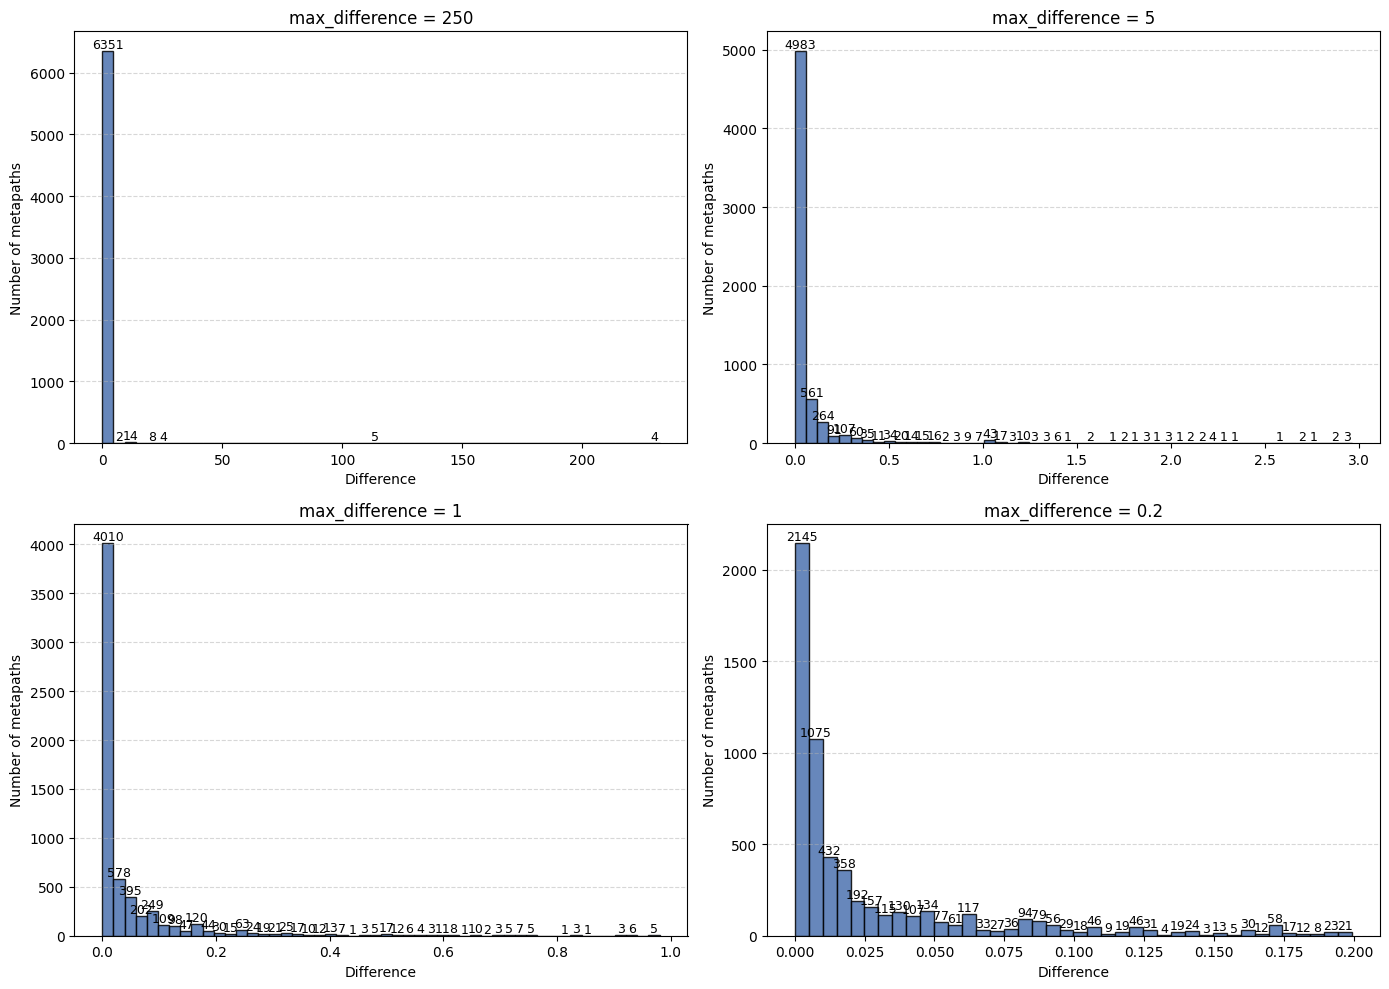

In [10]:
def plot_histogram(df: pd.DataFrame, bins: int, max_difference: float, interval_size: float = None, ax=None, ax_index: int = 0):
    """
    Plot histogram of abs_difference up to max_difference.
    If `interval_size` is provided, bins are calculated as max_difference / interval_size.
    Otherwise, uses the provided bins argument.
    If `ax` is None a new figure/axis is created.
    If `ax` is an array-like of axes (or a numpy.ndarray) the axis at ax_index is used.
    """
    # choose axis
    if ax is None:
        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)
    else:
        # handle numpy.ndarray, list, tuple, or similar containers of Axes
        try:
            # numpy.ndarray has flatten(); use it if available
            if hasattr(ax, "flatten"):
                ax = ax.flatten()[ax_index]
            else:
                ax = ax[ax_index]
        except Exception:
            # if ax is already a single Axes object, leave it
            pass

    # Calculate bins based on interval_size if provided
    if interval_size is not None:
        bins = max(1, int(max_difference / interval_size))

    filtered_df = df[df["abs_difference"] <= max_difference]
    ax.hist(
        filtered_df["abs_difference"],
        bins=bins,
        color="#4C72B0",
        edgecolor="black",
        alpha=0.85,
    )

    ax.set_xlabel("Difference")
    ax.set_ylabel("Number of metapaths")
    ax.set_title(f"max_difference = {max_difference}")
    ax.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate bar counts above each bin
    counts, bin_edges = np.histogram(
        filtered_df["abs_difference"],
        bins=bins,
    )
    for count, left_edge, right_edge in zip(counts, bin_edges[:-1], bin_edges[1:]):
        if count > 0:
            ax.text(
                (left_edge + right_edge) / 2,
                count,
                int(count),
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    return ax

fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df, 50, 250, ax=ax, ax_index=0, interval_size=5)
plot_histogram(df, 50, 5, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

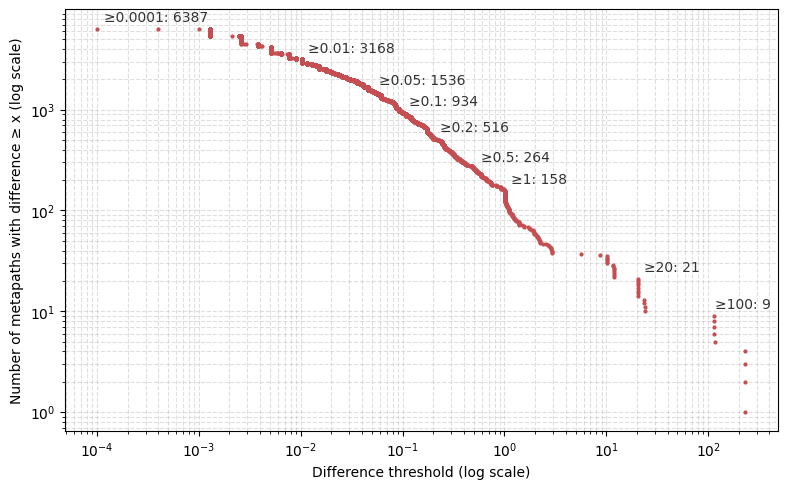

In [11]:
def compute_ccdf(values: np.ndarray):
    """Return (sorted_values, ccdf) where ccdf[i] = count of values >= sorted_values[i]."""
    sorted_vals = np.sort(values)[::-1]  # descending
    n = len(sorted_vals)
    ccdf_counts = np.arange(1, n + 1)  # rank of each value when sorted descending
    return sorted_vals, ccdf_counts
 
 
def plot_ccdf(df: pd.DataFrame, thresholds: list):
    values = df["abs_difference"].to_numpy()
    sorted_vals, ccdf_counts = compute_ccdf(values)
 
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sorted_vals, ccdf_counts, marker=".", linestyle="none", markersize=4, color="#C44E52")
 
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Difference threshold (log scale)")
    ax.set_ylabel("Number of metapaths with difference \u2265 x (log scale)")
    ax.grid(True, which="both", linestyle="--", alpha=0.4)
    
 
    # Annotate a few reference thresholds if they fall within range
    
    n_total = len(sorted_vals)
    for t in thresholds:
        count_ge_t = int((sorted_vals >= t).sum())
        if count_ge_t > 0:
            ax.annotate(
                f"\u2265{t}: {count_ge_t}",
                xy=(t, count_ge_t),
                xytext=(5, 5),
                textcoords="offset points",
                fontsize=10,
                color="#333333",
            )
 
    plt.tight_layout()
 
    # print(f"\nTotal metapaths: {n_total}")
    # print("Reference thresholds:")
    # for t in thresholds:
    #     count_ge_t = int((sorted_vals >= t).sum())
    #     print(f"  difference >= {t:>6}: {count_ge_t}")
    
    return plt.show()

thresholds = [0.0001, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 20, 100]
plot_ccdf(df, thresholds)

In [12]:
def min_threshold_for_percentage(df: pd.DataFrame, percentage: float, column: str = "difference") -> float:
    """
    Find the minimum 'difference' threshold t such that at least
    `percentage`% of the metapaths in df have difference >= t.
 
    In other words: what's the lowest bar I can set such that
    `percentage`% of the data still clears it?
 
    Parameters
    ----------
    df : pd.DataFrame
        Must contain the given `column` (default 'difference').
    percentage : float
        Target percentage of metapaths to retain, in (0, 100].
        e.g. 90 -> threshold below which 90% of metapaths remain (difference >= t).
    column : str
        Name of the numeric column to threshold on.
 
    Returns
    -------
    float
        The threshold value t.
    """
    if not (0 < percentage <= 100):
        raise ValueError("percentage must be in the range (0, 100]")
 
    values = df[column].dropna().to_numpy()
    if len(values) == 0:
        raise ValueError(f"No valid values found in column '{column}'")
 
    # We want: count(values >= t) / n >= percentage / 100
    # Equivalently: t is the (100 - percentage)-th percentile of the data,
    # using the "lower" interpolation so the guarantee (>= t) is not violated
    # by interpolated values that don't actually exist in the dataset.
    quantile_point = (100 - percentage) / 100
    threshold = np.quantile(values, quantile_point, method="lower")
 
    return float(threshold)
 
 
def thresholds_for_percentages(df: pd.DataFrame, percentages, column: str = "abs_difference") -> pd.DataFrame:
    """
    Convenience wrapper: compute thresholds for a list of percentages at once.
 
    Returns a DataFrame with columns: percentage, threshold, n_metapaths_retained
    """
    values = df[column].dropna().to_numpy()
    n_total = len(values)
 
    rows = []
    for p in percentages:
        t = min_threshold_for_percentage(df, p, column)
        n_retained = int((values >= t).sum())
        rows.append({
            "percentage": p,
            "threshold": t,
            "n_metapaths_retained": n_retained,
            "pct_actually_retained": round(100 * n_retained / n_total, 2),
        })
 
    return pd.DataFrame(rows)

thresholds_df = thresholds_for_percentages(df, [100, 50, 30, 20, 10, 5, 4, 2, 1, 0.5])
thresholds_df

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0000,6388,100.00
1,50.0,0.0090,3238,50.69
2,30.0,0.0345,1931,30.23
3,20.0,0.0665,1284,20.10
4,10.0,0.1726,652,10.21
5,5.0,0.3642,322,5.04
6,4.0,0.5064,257,4.02
7,2.0,1.0254,136,2.13
8,1.0,1.7877,65,1.02
9,0.5,10.1624,33,0.52


## Evaluation Runs

In [33]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [28]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.SINGLE,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "deepsad,tuningdme",

    "num_epochs": 100,
    "learning_rate": 0.005,
    "augment_factor": 0,
    "rm_semantic_fusion": True,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [29]:
# Run for 0.5%
dme_val = min_threshold_for_percentage(df, 0.5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

Early stopping: 15
Exporting data from database to CSV files... 
Splitting dataset into train/val/test sets with test size 15% and 5 folds for cross-validation.
Normalizing node features using min-max normalization.
Label distribution in train/val pool: 782 normal, 197 anomaly.
Identified 33 differential meta-paths for training.
Fold 1: centre initialised from 625 normal graphs.
Fold 1/5, epoch 1/100 — training...
  Fold 1, epoch 1, train loss: 7.2361, val loss: 0.6021, PR-AUC (anomaly): 0.4454, f2-score (anomaly): 0.3571, tau: 1.5556e+03
  dist(normal) 6.4000e-01+-0.0000e+00 | dist(anomaly) 5.3134e+02+-8.0014e+02
              precision    recall  f1-score   support

           0       0.85      1.00      0.92       157
           1       1.00      0.31      0.47        39

    accuracy                           0.86       196
   macro avg       0.93      0.65      0.70       196
weighted avg       0.88      0.86      0.83       196

Fold 1/5, epoch 2/100 — training...
  Fold 1, epoch

'/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/testing-single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge'

In [ ]:
# Run for 1%
dme_val = min_threshold_for_percentage(df, 1, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 2%
dme_val = min_threshold_for_percentage(df, 2, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 5%
dme_val = min_threshold_for_percentage(df, 5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 10%
dme_val = min_threshold_for_percentage(df, 10, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 20%
dme_val = min_threshold_for_percentage(df, 20, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

## Results processing

**NOTE:** Make sure to run the OUTPUTS_ROOT cell first (available in the section above) to set the correct path to the outputs directory.

In [34]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.005_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 6 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.0665_nosf_es15_deepsadbased__202608060931
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.1726_nosf_es15_deepsadbased__202608052203
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme0.3642_nosf_es15_deepsadbased__202608052152
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/single-internaltx-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.005_dme1.0254_nosf_es15_deepsadbased__202608052149
/home/go

In [35]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0665_nos...,0.0665,1267,0.195676,1152,0.2014
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1726_nos...,0.1726,597,0.092201,1152,0.2014
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3642_nos...,0.3642,322,0.049730,1152,0.2014
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.0254_nos...,1.0254,119,0.018378,1152,0.2014
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.7877_nos...,1.7877,65,0.010039,1152,0.2014
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme10.1624_no...,10.1624,33,0.005097,1152,0.2014


In [36]:
def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)
    
    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,test_loss_mean,test_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,mcc_mean,mcc_std,threshold_mean,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,44.153864,53.299813,0.961850,0.011902,0.992646,0.007996,0.959420,0.017512,0.975614,...,0.891678,0.029328,0.443294,0.310022,0.927382,0.022207,0.965424,0.013290,0.943893,0.016171
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,53.045064,43.835313,0.937572,0.008495,0.973634,0.013564,0.947826,0.019659,0.960289,...,0.817513,0.021560,0.124882,0.088000,0.896035,0.019107,0.922484,0.018747,0.906881,0.010879
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,17.636010,13.138399,0.928324,0.021813,0.994074,0.011852,0.915942,0.031619,0.952987,...,0.816817,0.044550,0.051399,0.037635,0.874074,0.030729,0.946542,0.019785,0.900652,0.026611
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,3.125787,2.094364,0.923699,0.032983,0.989560,0.016993,0.914493,0.043090,0.949835,...,0.804676,0.072129,0.191430,0.265174,0.871098,0.044319,0.937246,0.033881,0.894406,0.041231
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,3.843395,6.181309,0.853179,0.026765,0.989473,0.010284,0.824638,0.028028,0.899378,...,0.673866,0.054732,0.016570,0.009318,0.787346,0.027328,0.895176,0.027184,0.813768,0.031010
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,30.757629,22.722552,0.842775,0.006741,0.836992,0.004190,0.997101,0.003550,0.910056,...,0.427327,0.037745,2567.339600,1711.564999,0.894885,0.030775,0.615694,0.012100,0.642977,0.017499


In [37]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,350.818,103.479533,1754.09
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,195.348,55.142252,976.74
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,119.612,57.059426,598.06
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,35.140,6.009928,175.70
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,20.244,4.613175,101.22
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,9.018,0.347241,45.09


In [38]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.0665_nos...,0.0665,1267,0.195676,1152,0.2014,44.153864,53.299813,0.961850,...,0.310022,0.927382,0.022207,0.965424,0.013290,0.943893,0.016171,350.818,103.479533,1754.09
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.1726_nos...,0.1726,597,0.092201,1152,0.2014,53.045064,43.835313,0.937572,...,0.088000,0.896035,0.019107,0.922484,0.018747,0.906881,0.010879,195.348,55.142252,976.74
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme0.3642_nos...,0.3642,322,0.049730,1152,0.2014,17.636010,13.138399,0.928324,...,0.037635,0.874074,0.030729,0.946542,0.019785,0.900652,0.026611,119.612,57.059426,598.06
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.0254_nos...,1.0254,119,0.018378,1152,0.2014,3.125787,2.094364,0.923699,...,0.265174,0.871098,0.044319,0.937246,0.033881,0.894406,0.041231,35.140,6.009928,175.70
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme1.7877_nos...,1.7877,65,0.010039,1152,0.2014,3.843395,6.181309,0.853179,...,0.009318,0.787346,0.027328,0.895176,0.027184,0.813768,0.031010,20.244,4.613175,101.22
5,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.005_dme10.1624_no...,10.1624,33,0.005097,1152,0.2014,30.757629,22.722552,0.842775,...,1711.564999,0.894885,0.030775,0.615694,0.012100,0.642977,0.017499,9.018,0.347241,45.09


In [39]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,0.195676,1267,0.0665,0.961850,0.011902,0.992646,0.007996,0.959420,0.017512,0.975614,...,0.971429,0.031298,0.912171,0.024565,0.946431,0.021261,0.894856,0.054131,350.818,103.479533
1,0.092201,597,0.1726,0.937572,0.008495,0.973634,0.013564,0.947826,0.019659,0.960289,...,0.897143,0.052992,0.853473,0.016561,0.878401,0.031158,0.839580,0.034038,195.348,55.142252
2,0.049730,322,0.3642,0.928324,0.021813,0.994074,0.011852,0.915942,0.031619,0.952987,...,0.977143,0.045714,0.848317,0.038355,0.920195,0.030853,0.899230,0.031464,119.612,57.059426
3,0.018378,119,1.0254,0.923699,0.032983,0.989560,0.016993,0.914493,0.043090,0.949835,...,0.960000,0.066639,0.838978,0.060250,0.906005,0.052652,0.853571,0.056979,35.140,6.009928
4,0.010039,65,1.7877,0.853179,0.026765,0.989473,0.010284,0.824638,0.028028,0.899378,...,0.965714,0.033320,0.728158,0.042903,0.853943,0.036926,0.720348,0.031351,20.244,4.613175
5,0.005097,33,10.1624,0.842775,0.006741,0.836992,0.004190,0.997101,0.003550,0.910056,...,0.234286,0.021381,0.375899,0.031305,0.275848,0.024513,0.399965,0.012145,9.018,0.347241


In [40]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,19.57%,9.22%,4.97%,1.84%,1.00%,0.51%
reported_metapaths,1267,597,322,119,65,33
dme_threshold,0.0665,0.1726,0.3642,1.0254,1.7877,10.1624
accuracy,96.18 ± 01.19,93.76 ± 00.85,92.83 ± 02.18,92.37 ± 03.30,85.32 ± 02.68,84.28 ± 00.67
precision_normal,99.26 ± 00.80,97.36 ± 01.36,99.41 ± 01.19,98.96 ± 01.70,98.95 ± 01.03,83.70 ± 00.42
recall_normal,95.94 ± 01.75,94.78 ± 01.97,91.59 ± 03.16,91.45 ± 04.31,82.46 ± 02.80,99.71 ± 00.35
f1_normal,97.56 ± 00.79,96.03 ± 00.58,95.30 ± 01.51,94.98 ± 02.27,89.94 ± 01.92,91.01 ± 00.38
precision_anomaly,86.21 ± 04.77,81.84 ± 04.72,75.41 ± 06.61,75.26 ± 08.99,58.52 ± 04.71,95.28 ± 05.80
recall_anomaly,97.14 ± 03.13,89.71 ± 05.30,97.71 ± 04.57,96.00 ± 06.66,96.57 ± 03.33,23.43 ± 02.14
f1_anomaly,91.22 ± 02.46,85.35 ± 01.66,84.83 ± 03.84,83.90 ± 06.02,72.82 ± 04.29,37.59 ± 03.13
f2_anomaly,94.64 ± 02.13,87.84 ± 03.12,92.02 ± 03.09,90.60 ± 05.27,85.39 ± 03.69,27.58 ± 02.45


In [41]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lcccccc}
\toprule
pct_metapaths & 19.57% & 9.22% & 4.97% & 1.84% & 1.00% & 0.51% \\
\midrule
Reported Metapaths & 1267 & 597 & 322 & 119 & 65 & 33 \\
DME Threshold & 0.0665 & 0.1726 & 0.3642 & 1.0254 & 1.7877 & 10.1624 \\
Accuracy (\%) & $96.18 \pm 01.19$ & $93.76 \pm 00.85$ & $92.83 \pm 02.18$ & $92.37 \pm 03.30$ & $85.32 \pm 02.68$ & $84.28 \pm 00.67$ \\
Precision (Normal) (\%) & $99.26 \pm 00.80$ & $97.36 \pm 01.36$ & $99.41 \pm 01.19$ & $98.96 \pm 01.70$ & $98.95 \pm 01.03$ & $83.70 \pm 00.42$ \\
Recall (Normal) (\%) & $95.94 \pm 01.75$ & $94.78 \pm 01.97$ & $91.59 \pm 03.16$ & $91.45 \pm 04.31$ & $82.46 \pm 02.80$ & $99.71 \pm 00.35$ \\
F1 (Normal) (\%) & $97.56 \pm 00.79$ & $96.03 \pm 00.58$ & $95.30 \pm 01.51$ & $94.98 \pm 02.27$ & $89.94 \pm 01.92$ & $91.01 \pm 00.38$ \\
Precision (Anomaly) (\%) & $86.21 \pm 04.77$ & $81.84 \pm 04.72$ & $75.41 \pm 06.

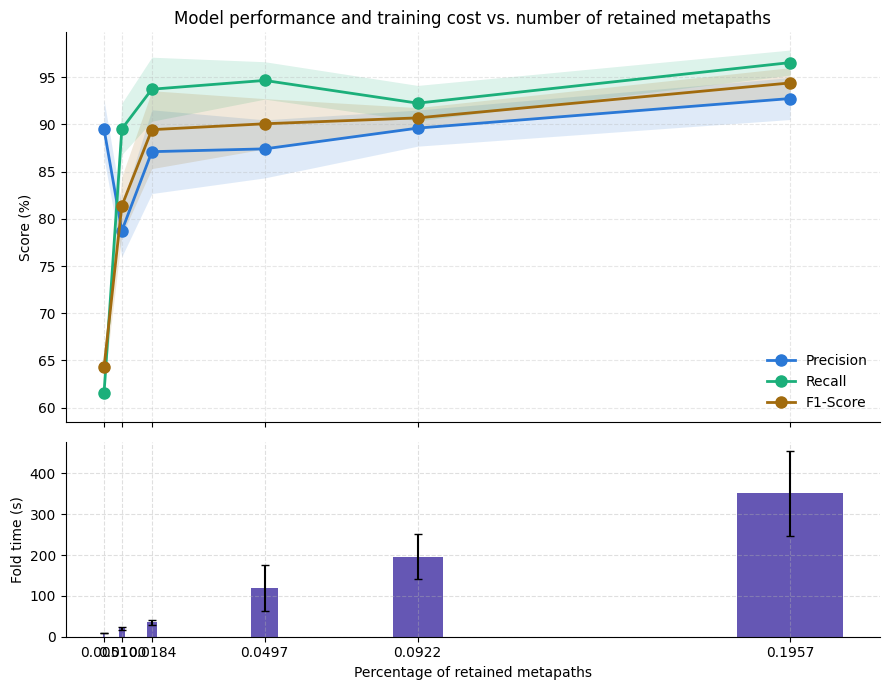

In [42]:
import matplotlib.pyplot as plt

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.set_title("Model performance and training cost vs. number of retained metapaths")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)

# --- Bottom panel: fold training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.bar(
    x, plot_df["fold_time_mean"], width=widths,
    yerr=plot_df["fold_time_std"], capsize=3,
    color=COLOR_TIME, alpha=0.85, edgecolor="none",
)
ax_time.set_ylabel("Fold time (s)")
ax_time.set_xlabel("Percentage of retained metapaths")
#ax_time.set_xscale("log")
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

ax_time.xaxis.set_major_locator(FixedLocator(x))

ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("dme_performance_vs_cost.svg", format="svg")
plt.show()


# CCTX Dataset

In [47]:
df2 = load_data("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/dme_report.csv")
df2["abs_difference"] = df2["difference"].abs()

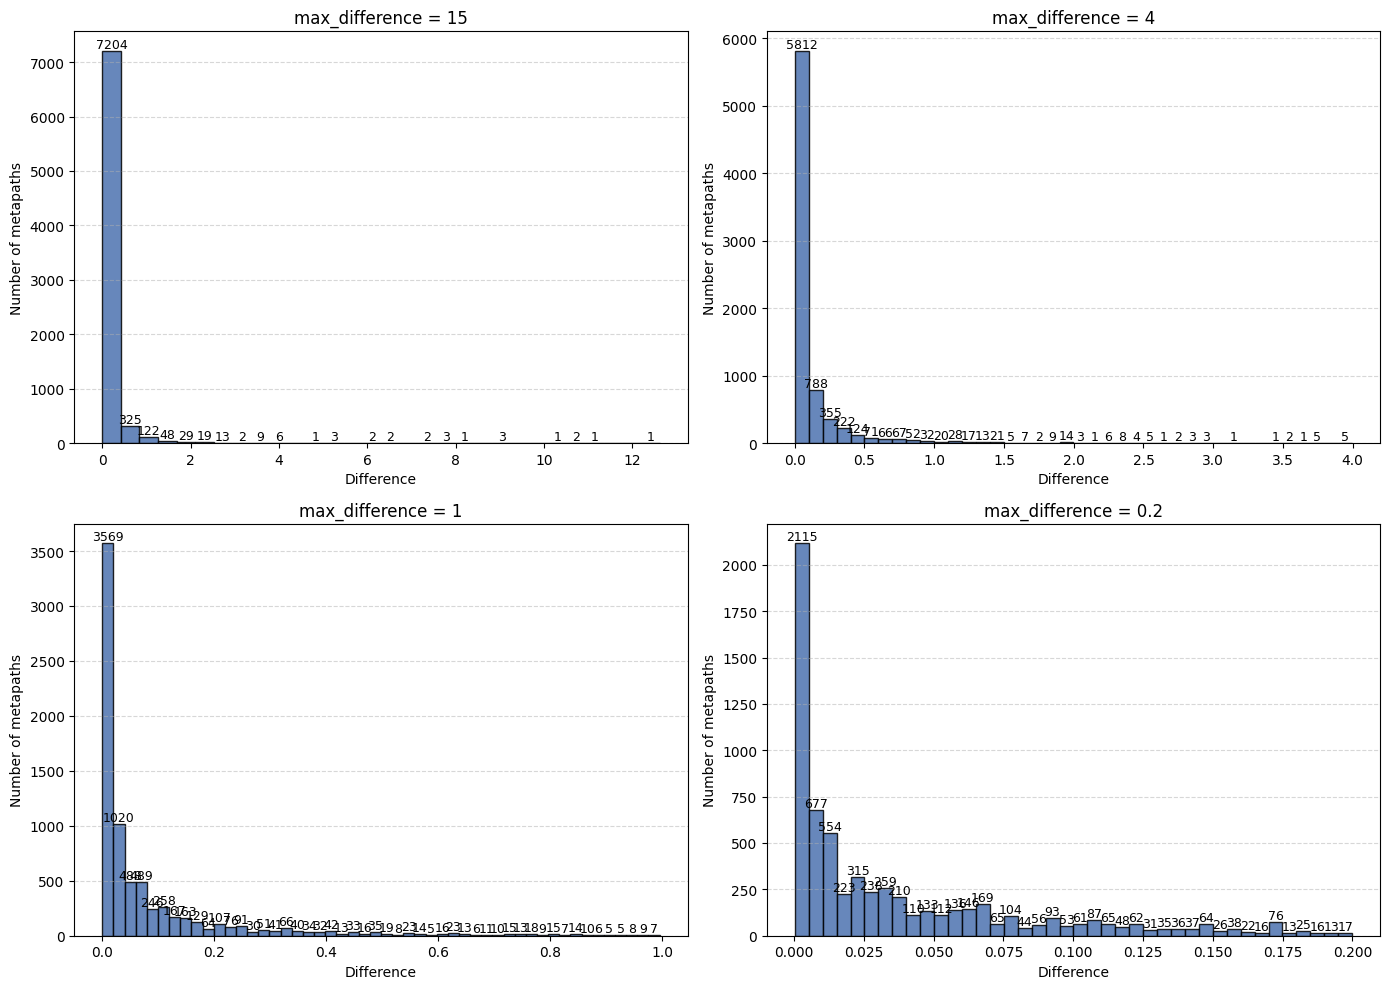

In [48]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))
plot_histogram(df2, 50, 15, ax=ax, ax_index=0, interval_size=0.5)
plot_histogram(df2, 50, 4, ax=ax, ax_index=1, interval_size=0.1)
plot_histogram(df2, 50, 1, ax=ax, ax_index=2, interval_size=0.02)
plot_histogram(df2, 50, 0.2, ax=ax, ax_index=3, interval_size=0.005)
plt.tight_layout()

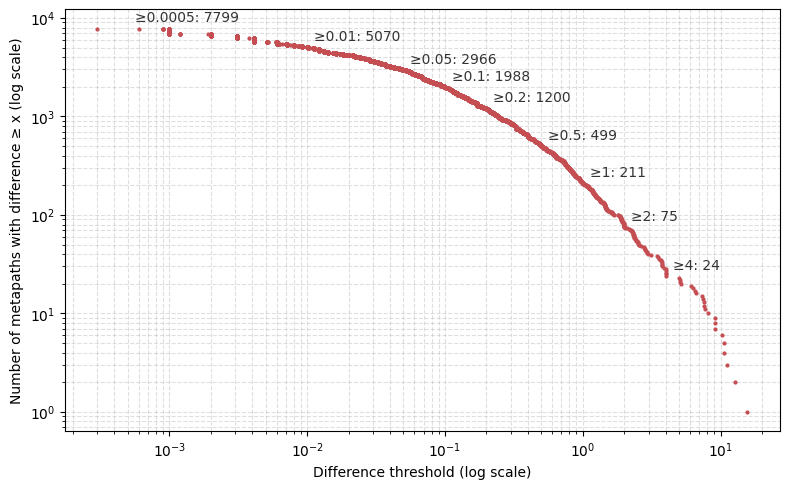

In [49]:
thresholds = [0.0005, 0.01, 0.05, 0.1, 0.2, 0.5, 1, 2, 4]
plot_ccdf(df2, thresholds)

In [50]:
thresholds_for_percentages(df2, [100, 50, 20, 10, 5, 2, 1, 0.5])

,percentage,threshold,n_metapaths_retained,pct_actually_retained
0,100.0,0.0003,7800,100.00
1,50.0,0.0254,3916,50.21
2,20.0,0.1404,1563,20.04
3,10.0,0.3266,790,10.13
4,5.0,0.6409,391,5.01
5,2.0,1.2350,157,2.01
6,1.0,1.9939,81,1.04
7,0.5,2.9705,40,0.51


## Evaluation Runs

In [57]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from types import SimpleNamespace

from cli import Cli
from dataset_generator.types import DATASET_TYPE

# Define the absolute path for the root directory for outputs here (and if possible, make sure to have a prepared _dataset folder)
OUTPUTS_ROOT = Path("/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge")

The next cells will run the model training for different metapath difference thresholds.

This process can take a long time to finish.

**If you already have the models trained, you can skip this section and go to the evaluation section.**

In [52]:
dataset_path = OUTPUTS_ROOT.absolute() / "_dataset"
fixed_args = {
    "device": "cpu",  # Change to "cuda" if you have a GPU and want to use it
    "dataset": DATASET_TYPE.CCTX,
    "load_data": str(dataset_path),
    "new_dataset": None,
    "force_reload": False,
    "num_workers": 0,
    "tags": "deepsad,tuningdme",

    "num_epochs": 100,
    # Notice that, for the CCTX scope in the new approach, 
    # the learning rate needs to be lowered
    "learning_rate": 0.002, 
    "augment_factor": 0,
    "rm_semantic_fusion": True,
    "early_stopping": 15,
    "kfolds": 5,
    "first_layer_channels": 128,
    "hidden_channels": 64,
    "dropout": 0.5,
    "input_drop": 0.0,
    "att_drop": 0.0,
    "n_fp_layers": 2,
    "n_mlp_layers": 2,
    "activation": "relu",
    "pooling": "mean",
    "residual": False,
    "random_seed": 42,
    "test_split": 0.15,
    "rep_dim": 64,
    "eta": 1.0,
    "deep_sad_eps": 1.0,
    "grad_clip": 1.0,
    "weight_decay": 1e-6,
    "ae_pretrain": False,
}

In [ ]:
# Run for 0.5%
dme_val = min_threshold_for_percentage(df2, 0.5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 1%
dme_val = min_threshold_for_percentage(df2, 1, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 2%
dme_val = min_threshold_for_percentage(df2, 2, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 5%
dme_val = min_threshold_for_percentage(df2, 5, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 10%
dme_val = min_threshold_for_percentage(df2, 10, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

In [ ]:
# Run for 20%
dme_val = min_threshold_for_percentage(df2, 20, column="abs_difference"),
Cli.train_model(SimpleNamespace(
    **fixed_args,
    dme_threshold=dme_val[0]
))

## Results processing

**NOTE:** Make sure to run the OUTPUTS_ROOT cell first (available in the section above) to set the correct path to the outputs directory.

In [59]:
# Obtain all relevant run directories that match the pattern and contain a params.yaml file
run_dirs = sorted(
    p for p in OUTPUTS_ROOT.glob("train_epochs100_augment0_lr0.002_dme*")
    if p.is_dir() and (p / "params.yaml").exists()
)

print(f"Found {len(run_dirs)} run directories")
for p in run_dirs:
    print(p)

Found 5 run directories
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme0.3266_nosf_es15_deepsadbased_tuningdme__202608061902
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme0.6409_nosf_es15_deepsadbased_tuningdme__202608061842
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme1.235_nosf_es15_deepsadbased_tuningdme__202608061833
/home/gonca/Documents/GitHub/IST-Thesis/BridgeDefender/outputs/cctx-internaltx-final-eval-tuningdme-ronin12-omni-nomad-polyn-qubit-harmony-thor123-meter-hypr-xbridge/train_epochs100_augment0_lr0.002_dme1.9939_

In [60]:
import yaml

def load_run_config(run_dir: Path) -> dict:
    TOTAL_METAPATHS = 6475  # Total number of metapaths in the dataset
    with open(run_dir / "params.yaml") as f:
        doc = yaml.safe_load(f)

    return {
        "run_dir": run_dir,
        "run_name": run_dir.name,
        "dme_threshold": doc["dme"]["dme_threshold"],
        "reported_metapaths": doc["dme"]["reported_metapaths"],
        "pct_metapaths": doc["dme"]["reported_metapaths"] / TOTAL_METAPATHS,
        "total_samples": doc["dataset"]["stats"]["total_samples"],
        "anomaly_ratio": doc["dataset"]["stats"]["anomaly_ratio"],
    }

configs = [load_run_config(p) for p in run_dirs]
configs_df = pd.DataFrame(configs)
configs_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.3266_nos...,0.3266,769,0.118764,1241,0.0677
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.6409_nos...,0.6409,381,0.058842,1241,0.0677
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.235_nosf...,1.2350,156,0.024093,1241,0.0677
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.9939_nos...,1.9939,75,0.011583,1241,0.0677
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme2.9705_nos...,2.9705,39,0.006023,1241,0.0677


In [61]:
def load_test_metrics(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "test_metrics.csv")
    metric_cols = [c for c in df.columns if c != "fold"]

    result = {"run_dir": run_dir}
    for col in metric_cols:
        result[f"{col}_mean"] = df[col].mean()
        result[f"{col}_std"] = df[col].std(ddof=0)

    result["precision_macro_mean"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).mean()
    result["precision_macro_std"] = ((df["precision_normal"] + df["precision_anomaly"]) / 2).std(ddof=0)
    result["recall_macro_mean"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).mean()
    result["recall_macro_std"] = ((df["recall_normal"] + df["recall_anomaly"]) / 2).std(ddof=0)
    result["f1_macro_mean"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).mean()
    result["f1_macro_std"] = ((df["f1_normal"] + df["f1_anomaly"]) / 2).std(ddof=0)
    return result

metrics = [load_test_metrics(p) for p in run_dirs]
metrics_df = pd.DataFrame(metrics)
metrics_df

,run_dir,test_loss_mean,test_loss_std,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,mcc_mean,mcc_std,threshold_mean,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,3.101573,4.084518,0.982888,0.004002,0.989707,0.004217,0.991954,0.004598,0.990814,...,0.867042,0.030606,30.330202,58.153860,0.941404,0.022514,0.926746,0.027622,0.932762,0.015895
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.138518,0.148760,0.910160,0.113056,0.980535,0.012699,0.920690,0.115995,0.946101,...,0.639219,0.242189,0.746104,1.095192,0.804278,0.134305,0.844960,0.107578,0.802136,0.149354
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.049574,0.001617,0.854545,0.137690,0.973507,0.016208,0.866667,0.146587,0.910532,...,0.515384,0.280939,0.070084,0.069002,0.765049,0.182028,0.779487,0.126689,0.717541,0.173783
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.071690,0.012640,0.884492,0.090600,0.982030,0.006387,0.891954,0.096811,0.932086,...,0.545185,0.188698,0.172555,0.335530,0.729412,0.118329,0.838285,0.063401,0.744853,0.122276
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,0.586978,0.013187,0.181818,0.007563,1.000000,0.000000,0.120690,0.008128,0.215291,...,0.097181,0.003691,0.549010,0.181979,0.539159,0.000334,0.560345,0.004064,0.180276,0.007046


In [62]:
def load_fold_durations(run_dir: Path) -> dict:
    df = pd.read_csv(run_dir / "fold_durations.csv")
    return {
        "run_dir": run_dir,
        "fold_time_mean": df["time"].mean(),
        "fold_time_std": df["time"].std(ddof=0),  # match summary.txt convention
        "fold_time_total": df["time"].sum(),
    }

durations = [load_fold_durations(p) for p in run_dirs]
durations_df = pd.DataFrame(durations)
durations_df


,run_dir,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,357.562,89.138195,1787.81
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,227.790,85.826395,1138.95
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,94.814,47.467246,474.07
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,67.110,29.771030,335.55
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,16.510,2.234636,82.55


In [63]:
comparison_df = (
    configs_df
    .merge(metrics_df, on="run_dir")
    .merge(durations_df, on="run_dir")
    .sort_values(["dme_threshold"])
    .reset_index(drop=True)
)
comparison_df

,run_dir,run_name,dme_threshold,reported_metapaths,pct_metapaths,total_samples,anomaly_ratio,test_loss_mean,test_loss_std,accuracy_mean,...,threshold_std,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std,fold_time_mean,fold_time_std,fold_time_total
0,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.3266_nos...,0.3266,769,0.118764,1241,0.0677,3.101573,4.084518,0.982888,...,58.153860,0.941404,0.022514,0.926746,0.027622,0.932762,0.015895,357.562,89.138195,1787.81
1,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme0.6409_nos...,0.6409,381,0.058842,1241,0.0677,0.138518,0.148760,0.910160,...,1.095192,0.804278,0.134305,0.844960,0.107578,0.802136,0.149354,227.790,85.826395,1138.95
2,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.235_nosf...,1.2350,156,0.024093,1241,0.0677,0.049574,0.001617,0.854545,...,0.069002,0.765049,0.182028,0.779487,0.126689,0.717541,0.173783,94.814,47.467246,474.07
3,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme1.9939_nos...,1.9939,75,0.011583,1241,0.0677,0.071690,0.012640,0.884492,...,0.335530,0.729412,0.118329,0.838285,0.063401,0.744853,0.122276,67.110,29.771030,335.55
4,/home/gonca/Documents/GitHub/IST-Thesis/Bridge...,train_epochs100_augment0_lr0.002_dme2.9705_nos...,2.9705,39,0.006023,1241,0.0677,0.586978,0.013187,0.181818,...,0.181979,0.539159,0.000334,0.560345,0.004064,0.180276,0.007046,16.510,2.234636,82.55


In [64]:
trimmed_df = comparison_df[[
    "pct_metapaths", 
    "reported_metapaths",
    "dme_threshold",
    "accuracy_mean",
    "accuracy_std",
    "precision_normal_mean",
    "precision_normal_std",
    "recall_normal_mean",
    "recall_normal_std",
    "f1_normal_mean",
    "f1_normal_std",
    "precision_anomaly_mean",
    "precision_anomaly_std",
    "recall_anomaly_mean",
    "recall_anomaly_std",
    "f1_anomaly_mean",
    "f1_anomaly_std",
    "f2_anomaly_mean",
    "f2_anomaly_std",
    "pr_auc_mean",
    "pr_auc_std",
    "fold_time_mean",
    "fold_time_std",
]]
trimmed_df

,pct_metapaths,reported_metapaths,dme_threshold,accuracy_mean,accuracy_std,precision_normal_mean,precision_normal_std,recall_normal_mean,recall_normal_std,f1_normal_mean,...,recall_anomaly_mean,recall_anomaly_std,f1_anomaly_mean,f1_anomaly_std,f2_anomaly_mean,f2_anomaly_std,pr_auc_mean,pr_auc_std,fold_time_mean,fold_time_std
0,0.118764,769,0.3266,0.982888,0.004002,0.989707,0.004217,0.991954,0.004598,0.990814,...,0.861538,0.057564,0.874711,0.029719,0.866200,0.043477,0.863182,0.035525,357.562,89.138195
1,0.058842,381,0.6409,0.910160,0.113056,0.980535,0.012699,0.920690,0.115995,0.946101,...,0.769231,0.128717,0.658171,0.227738,0.701632,0.190737,0.786735,0.176067,227.790,85.826395
2,0.024093,156,1.2350,0.854545,0.137690,0.973507,0.016208,0.866667,0.146587,0.910532,...,0.692308,0.200591,0.524550,0.264077,0.575766,0.228239,0.647667,0.187668,94.814,47.467246
3,0.011583,75,1.9939,0.884492,0.090600,0.982030,0.006387,0.891954,0.096811,0.932086,...,0.784615,0.075369,0.557619,0.189797,0.654034,0.133511,0.573290,0.162397,67.110,29.771030
4,0.006023,39,2.9705,0.181818,0.007563,1.000000,0.000000,0.120690,0.008128,0.215291,...,1.000000,0.000000,0.145260,0.001148,0.298178,0.001934,0.078600,0.000484,16.510,2.234636


In [65]:
PCT_SCALE_EXCLUDE = {"fold_time"}  # keep seconds as seconds, not *100

def format_stat(mean, std, base):
    scale = 1 if base in PCT_SCALE_EXCLUDE else 100
    return f"{mean * scale:.2f} \u00b1 {std * scale:05.2f}"

metric_bases = [c[:-5] for c in trimmed_df.columns if c.endswith("_mean")]

display_df = pd.DataFrame(index=trimmed_df.index)
display_df["reported_metapaths"] = trimmed_df["reported_metapaths"].map(lambda v: f"{v:.0f}")
display_df["dme_threshold"] = trimmed_df["dme_threshold"].map(lambda v: f"{v:.4f}")
for base in metric_bases:
    display_df[base] = trimmed_df.apply(
        lambda row: format_stat(row[f"{base}_mean"], row[f"{base}_std"], base), axis=1
    )

display_df.insert(0, "pct_metapaths", (trimmed_df["pct_metapaths"]*100).map(lambda v: f"{v:.2f}%"))
display_df = display_df.set_index("pct_metapaths")

final_table = display_df.T
final_table


pct_metapaths,11.88%,5.88%,2.41%,1.16%,0.60%
reported_metapaths,769,381,156,75,39
dme_threshold,0.3266,0.6409,1.2350,1.9939,2.9705
accuracy,98.29 ± 00.40,91.02 ± 11.31,85.45 ± 13.77,88.45 ± 09.06,18.18 ± 00.76
precision_normal,98.97 ± 00.42,98.05 ± 01.27,97.35 ± 01.62,98.20 ± 00.64,100.00 ± 00.00
recall_normal,99.20 ± 00.46,92.07 ± 11.60,86.67 ± 14.66,89.20 ± 09.68,12.07 ± 00.81
f1_normal,99.08 ± 00.22,94.61 ± 07.18,91.05 ± 08.84,93.21 ± 05.68,21.53 ± 01.29
precision_anomaly,89.31 ± 04.68,62.80 ± 25.97,55.66 ± 36.00,47.68 ± 23.43,7.83 ± 00.07
recall_anomaly,86.15 ± 05.76,76.92 ± 12.87,69.23 ± 20.06,78.46 ± 07.54,100.00 ± 00.00
f1_anomaly,87.47 ± 02.97,65.82 ± 22.77,52.45 ± 26.41,55.76 ± 18.98,14.53 ± 00.11
f2_anomaly,86.62 ± 04.35,70.16 ± 19.07,57.58 ± 22.82,65.40 ± 13.35,29.82 ± 00.19


In [66]:
# Turn the unicode ± into LaTeX math syntax, and escape underscores in row labels
import re

METRIC_LABELS = {
    "reported_metapaths": "Reported Metapaths",
    "dme_threshold": "DME Threshold",
    "test_loss": "Test Loss (\\%)",
    "accuracy": "Accuracy (\\%)",
    "precision_normal": "Precision (Normal) (\\%)",
    "recall_normal": "Recall (Normal) (\\%)",
    "f1_normal": "F1 (Normal) (\\%)",
    "precision_anomaly": "Precision (Anomaly) (\\%)",
    "recall_anomaly": "Recall (Anomaly) (\\%)",
    "f1_anomaly": "F1 (Anomaly) (\\%)",
    "f2_anomaly": "F2 (Anomaly) (\\%)",
    "pr_auc": "PR-AUC (\\%)",
    "fold_time": "Fold Training Time (sec/fold)",
}

def to_math_pm(s: str) -> str:
    return re.sub(r"(-?[\d.]+) \u00b1 (-?[\d.]+)", r"$\1 \\pm \2$", s)

latex_ready = final_table.map(to_math_pm)
latex_ready = latex_ready.rename(index=METRIC_LABELS)
latex_ready.index = latex_ready.index.str.replace("_", r"\_", regex=False)

latex_str = latex_ready.to_latex(
    escape=False,  # cell values already contain LaTeX ($\pm$), don't double-escape
    column_format="l" + "c" * len(latex_ready.columns),
    caption="Effect of the DME threshold on test-set performance",
    label="tab:dme_threshold_comparison",
)
print(latex_str)

with open("dme_threshold_comparison.tex", "w") as f:
    f.write(latex_str)


\begin{table}
\caption{Effect of the DME threshold on test-set performance}
\label{tab:dme_threshold_comparison}
\begin{tabular}{lccccc}
\toprule
pct_metapaths & 11.88% & 5.88% & 2.41% & 1.16% & 0.60% \\
\midrule
Reported Metapaths & 769 & 381 & 156 & 75 & 39 \\
DME Threshold & 0.3266 & 0.6409 & 1.2350 & 1.9939 & 2.9705 \\
Accuracy (\%) & $98.29 \pm 00.40$ & $91.02 \pm 11.31$ & $85.45 \pm 13.77$ & $88.45 \pm 09.06$ & $18.18 \pm 00.76$ \\
Precision (Normal) (\%) & $98.97 \pm 00.42$ & $98.05 \pm 01.27$ & $97.35 \pm 01.62$ & $98.20 \pm 00.64$ & $100.00 \pm 00.00$ \\
Recall (Normal) (\%) & $99.20 \pm 00.46$ & $92.07 \pm 11.60$ & $86.67 \pm 14.66$ & $89.20 \pm 09.68$ & $12.07 \pm 00.81$ \\
F1 (Normal) (\%) & $99.08 \pm 00.22$ & $94.61 \pm 07.18$ & $91.05 \pm 08.84$ & $93.21 \pm 05.68$ & $21.53 \pm 01.29$ \\
Precision (Anomaly) (\%) & $89.31 \pm 04.68$ & $62.80 \pm 25.97$ & $55.66 \pm 36.00$ & $47.68 \pm 23.43$ & $7.83 \pm 00.07$ \\
Recall (Anomaly) (\%) & $86.15 \pm 05.76$ & $76.92 \pm 12.8

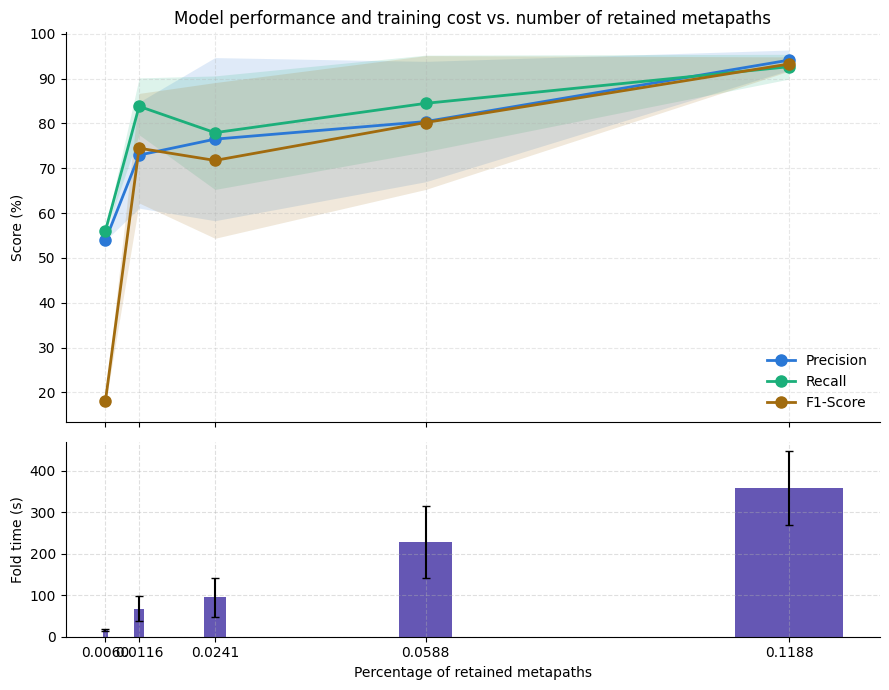

In [67]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

# Palette (dataviz skill's validated categorical slots):
#   slot 1 (blue) / slot 2 (aqua) for the two performance lines,
#   slot 5 (violet) for the single-series bar panel — kept out of the
#   line panel's hue range so it doesn't read as a third "performance" series.
COLOR_PRECISION = "#2a78d6"
COLOR_RECALL = "#1baf7a"
COLOR_F1 = "#a16b0e"
COLOR_TIME = "#4a3aa7"

plot_df = comparison_df.sort_values("pct_metapaths")
x = plot_df["pct_metapaths"].to_numpy()

fig, (ax_perf, ax_time) = plt.subplots(
    2, 1, figsize=(9, 7), sharex=True, height_ratios=[2, 1]
)

# --- Top panel: accuracy & PR-AUC, mean line + std band ---
for col, color, label in [
    ("precision_macro", COLOR_PRECISION, "Precision"),
    ("recall_macro", COLOR_RECALL, "Recall"),
    ("f1_macro", COLOR_F1, "F1-Score"),
]:
    mean = plot_df[f"{col}_mean"].to_numpy() * 100
    std = plot_df[f"{col}_std"].to_numpy() * 100
    ax_perf.plot(x, mean, color=color, linewidth=2, marker="o", markersize=8, label=label)
    ax_perf.fill_between(x, mean - std, mean + std, color=color, alpha=0.15, linewidth=0)

ax_perf.set_ylabel("Score (%)")
ax_perf.set_title("Model performance and training cost vs. number of retained metapaths")
ax_perf.legend(frameon=False)
ax_perf.grid(axis="x", linestyle="--", alpha=0.3)
ax_perf.grid(axis="y", linestyle="--", alpha=0.3)
ax_perf.spines[["top", "right"]].set_visible(False)

# --- Bottom panel: fold training time, bars + std error bars ---
# bar width as a fraction of x so bars read consistently on a log x-axis
widths = x * 0.15
ax_time.bar(
    x, plot_df["fold_time_mean"], width=widths,
    yerr=plot_df["fold_time_std"], capsize=3,
    color=COLOR_TIME, alpha=0.85, edgecolor="none",
)
ax_time.set_ylabel("Fold time (s)")
ax_time.set_xlabel("Percentage of retained metapaths")
#ax_time.set_xscale("log")

ax_time.xaxis.set_major_locator(FixedLocator(x))

ax_time.grid(True, axis="both", linestyle="--", alpha=0.4)
ax_time.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig("dme_performance_vs_cost.svg", format="svg")
plt.show()
